# 02: What a market resolves on

**The question this notebook answers:** what number does a temperature market actually pay out
on, and can it be rebuilt from the raw station reports?

A market titled *Highest temperature in NYC on 15 July* does not resolve on a climate report. It
resolves on a web page: the highest value shown for one named station over the local day. The page
converts units and rounds before it shows anything. A model that predicts the true maximum to a
tenth of a degree is still predicting the wrong number if it does not know how the page rounds.

**The answer it arrives at:** the highest displayed value over the local clock day. For a Fahrenheit
market that is each report's tenth-of-a-degree Celsius temperature, converted to Fahrenheit and
rounded half up. For a Celsius market it is the whole-degree METAR value. Rebuilt this way, the
label lands in the bucket Polymarket paid out on 99.7% of Fahrenheit days and 97 to 99% of Celsius
days. The days that match nothing are listed and explained at the end.

## Setup

In [1]:
import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from weather_edge import config, plots
from weather_edge.observations import c_to_f, parse_metar_temps

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 120)

con = duckdb.connect(str(config.RESEARCH_DB), read_only=True)
con.execute("SET enable_progress_bar=false")

def q(sql, params=None):
    return con.execute(sql, params or []).df()

## One market, and what its rules say

**Every market carries its own rules text, and the rules changed over time.** Most of the history
resolved on Weather Underground's daily history page. Since late August 2026 almost every city
resolves on weather.gov's hourly table instead, and Hong Kong has always used the Observatory's own
daily maximum. Each market is graded by the rule in its own text, never by a global setting.

In [2]:
buckets = q("""
    SELECT market_id, bucket_label, bucket_lo, bucket_hi, unit, resolution_source, is_winner,
           round(volume_usd) AS volume_usd, created_at
    FROM markets
    WHERE station = 'KLGA' AND date = DATE '2025-07-15'
    ORDER BY bucket_lo NULLS FIRST
""")
buckets

,market_id,bucket_label,bucket_lo,bucket_hi,unit,resolution_source,is_winner,volume_usd,created_at
0,562360,81°F or below,<NA>,81,F,wunderground,False,14027.0,2025-07-11 08:47:08.640364
1,562362,82-83°F,82,83,F,wunderground,False,4795.0,2025-07-11 08:47:09.432839
2,562364,84-85°F,84,85,F,wunderground,False,3764.0,2025-07-11 08:47:10.236552
3,562366,86-87°F,86,87,F,wunderground,True,2615.0,2025-07-11 08:47:11.055496
4,562368,88-89°F,88,89,F,wunderground,False,5397.0,2025-07-11 08:47:11.927526
5,562370,90-91°F,90,91,F,wunderground,False,5059.0,2025-07-11 08:47:12.795769
6,562372,92°F or higher,92,<NA>,F,wunderground,False,9744.0,2025-07-11 08:47:13.716291


In [3]:
rules = con.execute(
    "SELECT rules_text FROM rules_history WHERE market_id = ?", [buckets.market_id.iloc[0]]
).fetchone()[0]
print(rules)

This market will resolve to the temperature range that contains the highest temperature recorded at the LaGuardia Airport Station in degrees Fahrenheit on 15 Jul '25.

The resolution source for this market will be information from Wunderground, specifically the highest temperature recorded for all times on this day by the Forecast for the LaGuardia Airport Station once information is finalized, available here: https://www.wunderground.com/history/daily/us/ny/new-york-city/KLGA.

This market can not resolve to "Yes" until all data for this date has been finalized.

The resolution source for this market measures temperatures to whole degrees Fahrenheit (eg, 21°F). Thus, this is the level of precision that will be used when resolving the market.

Any revisions to temperatures recorded after data is finalized for this market's timeframe will not be considered for this market's resolution.


### What the rules pin down

Three things matter in that text: the station is LaGuardia, the page is Weather Underground's
history page for KLGA, and the value is in **whole degrees Fahrenheit**. It does not say how the
page gets from a station report to a whole degree. That is the part to work out.

## What one station report contains

**A METAR carries the temperature twice.** The body has it in whole degrees Celsius (`23/21` is 23
°C with a 21 °C dew point). US stations also append a T group in the remarks, `T02330211`, which is
the same reading in tenths: 23.3 °C. The difference between the two decides the displayed
Fahrenheit value more often than you would think.

In [4]:
reports = q("""
    SELECT obs_time_utc, raw, temp_c_whole, temp_c_tenths
    FROM observations
    WHERE station = 'KLGA' AND obs_time_utc::DATE = DATE '2025-07-15'
    ORDER BY obs_time_utc
""")
print(len(reports), "reports on the day")
reports.head(6)

40 reports on the day


,obs_time_utc,raw,temp_c_whole,temp_c_tenths
0,2025-07-15 00:22:00,KLGA 150022Z 04006KT 3SM TSRA BR FEW025 BKN040CB OVC090 23/21 A3005 RMK AO2 OCNL LTGICCCCG OHD-E TS OHD-E MOV E P001...,23.0,23.3
1,2025-07-15 00:51:00,KLGA 150051Z 08008KT 3SM TSRA BR FEW029 SCT050CB OVC100 23/21 A3005 RMK AO2 SFC VIS 4 SLP175 OCNL LTGICCC E-S TS E-S...,23.0,22.8
2,2025-07-15 01:02:00,KLGA 150102Z 08010KT 3SM RA BR FEW029 SCT050 BKN120 OVC200 23/21 A3005 RMK AO2 SFC VIS 5 TSE01 P0004 T02280211 $,23.0,22.8
3,2025-07-15 01:51:00,KLGA 150151Z 06005KT 10SM -RA FEW037 BKN050 OVC130 23/21 A3005 RMK AO2 TSE01 SLP176 P0011 T02330211 $,23.0,23.3
4,2025-07-15 02:29:00,KLGA 150229Z 05004KT 10SM -RA BKN017 OVC130 23/21 A3006 RMK AO2 P0001 T02280211 $,23.0,22.8
5,2025-07-15 02:51:00,KLGA 150251Z 04004KT 10SM -RA FEW010 BKN018 BKN050 OVC130 23/21 A3005 RMK AO2 SLP177 P0001 60034 T02330211 51003 $,23.0,23.3


In [5]:
example = reports.raw.iloc[0]
whole, tenths = parse_metar_temps(example)

print("report:", example)
print("whole degrees:", whole, "C ->", c_to_f(whole), "F")
print("tenths:       ", tenths, "C ->", c_to_f(tenths), "F")

report: KLGA 150022Z 04006KT 3SM TSRA BR FEW025 BKN040CB OVC090 23/21 A3005 RMK AO2 OCNL LTGICCCCG OHD-E TS OHD-E MOV E P0013 T02330211 $
whole degrees: 23 C -> 73 F
tenths:        23.3 C -> 74 F


### The same report, two Fahrenheit values

23 °C converts to 73.4 °F and displays as 73. 23.3 °C converts to 73.94 °F and displays as 74. One
report, one degree apart, and the markets are two degrees wide. Which of the two the page uses is
the question.

## The two candidate rules leave different fingerprints

**If the page rounded the whole-degree Celsius value, some Fahrenheit integers could never appear.**
23 °C becomes 73 and 24 °C becomes 75, so 74 would be impossible. That is a testable claim: rebuild
every LaGuardia day under both rules and look at which values show up.

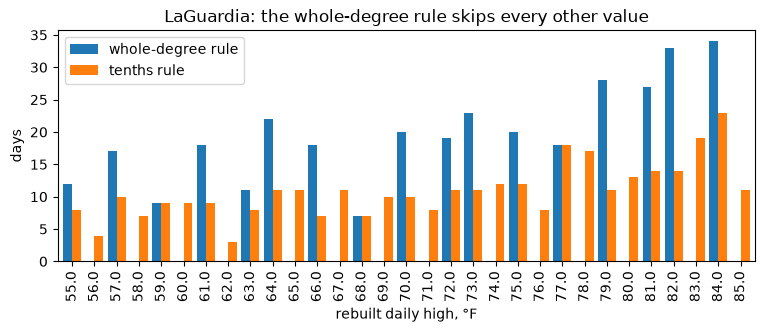

values between 60 and 80 that never occur under the whole-degree rule:
[60.0, 62.0, 65.0, 67.0, 69.0, 71.0, 74.0, 76.0, 78.0, 80.0]


In [6]:
klga = q("""
    SELECT date, whole, tenths, resolved_bucket, match_whole, match_tenths
    FROM truth
    WHERE station = 'KLGA' AND unit = 'F' AND n_obs > 0
""")

counts = pd.DataFrame({
    "whole-degree rule": klga.whole.value_counts(),
    "tenths rule": klga.tenths.value_counts(),
}).fillna(0).astype(int).sort_index()

fig, ax = plt.subplots(figsize=(9, 3))
counts.loc[55:85].plot.bar(ax=ax, width=0.8)
ax.set_xlabel("rebuilt daily high, °F")
ax.set_ylabel("days")
ax.set_title("LaGuardia: the whole-degree rule skips every other value")
plt.show()

print("values between 60 and 80 that never occur under the whole-degree rule:")
print(counts.loc[60:80].query("`whole-degree rule` == 0").index.tolist())

### The gaps are in the rule, not in the weather

Under the whole-degree rule ten of the 21 values from 60 to 80 °F never happen at LaGuardia: 60, 62,
65, 67, 69, 71, 74, 76, 78 and 80. Under the tenths rule every value occurs. Polymarket paid out on buckets containing those "impossible" values
many times, so the page cannot be rounding the whole-degree Celsius. It uses the tenths.

That also kills the idea I started with, that some buckets are structurally underpriced because of
the rounding chain. There is no such bucket.

## Rebuilding every resolved event

**Now the same rebuild for all 11,240 resolved events, by resolution source and unit.** A match
means the rebuilt high falls inside the bucket Polymarket resolved. `whole` is the whole-degree
rule, `tenths` the T-group rule, `routine` the whole-degree rule on routine reports only (no SPECI
reports between the hours).

In [7]:
by_era = q("""
    SELECT era, unit, count(*) AS n_events,
           round(avg(match_whole::int), 4) AS whole,
           round(avg(match_tenths::int), 4) AS tenths,
           round(avg(match_routine::int), 4) AS routine
    FROM truth
    WHERE station <> 'HKO' AND n_obs > 0
    GROUP BY 1, 2
    ORDER BY 3 DESC
""")
by_era

,era,unit,n_events,whole,tenths,routine
0,wunderground,C,5894,0.9708,0.9708,0.9639
1,wunderground,F,2863,0.8222,0.9972,0.8180
2,noaa_wrh,C,1822,0.9857,0.9857,0.9885
3,noaa_wrh,F,407,0.7715,0.9975,0.7690


In [8]:
# Hong Kong is graded against the Observatory's published daily maximum, not METARs;
# the observations stage writes that check into the report
hong_kong = plots.table_after(
    plots.read_tables(config.REPORTS / "phase3_ground_truth.md"), "Hong Kong", "match_floor"
)
hong_kong

,n_events,with_daily_max,match_floor,match_round
0,196.0,168.0,0.9881,0.5298


### What we got

| source | unit | events | whole-degree rule | tenths rule |
|---|---|---|---|---|
| Weather Underground | °F | 2,863 | 82.2% | **99.7%** |
| Weather Underground | °C | 5,894 | **97.1%** | 97.1% |
| weather.gov | °F | 407 | 77.2% | **99.8%** |
| weather.gov | °C | 1,822 | **98.6%** | 98.6% |
| Hong Kong Observatory | °C | 168 | | **98.8%** |

**Fahrenheit markets need the tenths, Celsius markets do not.** For Celsius the two rules give the
same answer, which is what you expect: the whole-degree METAR value is already what a Celsius page
shows. Hong Kong resolves on the Observatory's published daily maximum with the decimal cut off, so
a "33 °C" bucket covers 33.0 to 33.9. 168 of its 196 market days have a published maximum and 166
of those match.

The one rule that never wins is `routine`. SPECI reports, the extra ones a station files when the
weather changes, do count on the page. A peak that only shows up in a SPECI still resolves the
market.

## The days that match nothing

**205 events match neither rule.** They are not spread evenly. Most sit in two cities and on one
date.

In [9]:
unmatched = q("""
    SELECT city, date, unit, era, resolved_bucket, whole, tenths, n_obs
    FROM truth
    WHERE station <> 'HKO' AND n_obs > 0 AND NOT match_whole AND NOT match_tenths
""")
print(len(unmatched), "unmatched events")
print()
print("by city:")
print(unmatched.city.value_counts().head(6).to_string())
print()
print("by date:")
print(unmatched.date.value_counts().head(4).to_string())

205 unmatched events

by city:
city
Shenzhen       119
Seoul           30
Moscow          11
Taipei           8
Panama City      4
Sao Paulo        3

by date:
date
2026-05-19    21
2026-09-20     5
2026-05-17     4
2026-05-24     3


In [10]:
# 19 May 2026: every city was listed twice, under a plain slug and an "arch-" slug
doubles = q("""
    SELECT city, date, count(DISTINCT event_id) AS events,
           count(DISTINCT resolved_bucket) AS distinct_outcomes
    FROM truth
    GROUP BY 1, 2
    HAVING count(DISTINCT event_id) > 1
    ORDER BY 1
""")
print(len(doubles), "city-days with two events, all on", doubles.date.dt.date.unique()[0])
print((doubles.distinct_outcomes > 1).sum(), "of them resolved to two different buckets")
print()
q("""
    SELECT t.event_id, m.event_slug, t.resolved_bucket, t.tenths AS rebuilt_high
    FROM truth t JOIN (SELECT DISTINCT event_id, event_slug FROM markets) m USING (event_id)
    WHERE t.city = 'Atlanta' AND t.date = DATE '2026-05-19'
""")

46 city-days with two events, all on 2026-05-19
40 of them resolved to two different buckets



,event_id,event_slug,resolved_bucket,rebuilt_high
0,503612,highest-temperature-in-atlanta-on-may-19-2026,89°F or below,88.0
1,493660,arch-highest-temperature-in-atlanta-on-may-19-2026,96-97°F,88.0


In [11]:
shenzhen = unmatched[unmatched.city == "Shenzhen"]
gap = shenzhen.resolved_bucket.str.extract(r"(-?\d+)")[0].astype(float) - shenzhen.whole

print("Shenzhen: resolved bucket minus rebuilt high, in °C")
print(gap.value_counts().sort_index().to_string())

Shenzhen: resolved bucket minus rebuilt high, in °C
-2.0    11
-1.0    24
 1.0    49
 2.0    28
 3.0     6
 4.0     1


### Three stories, not one

**Shenzhen, 119 events.** The page's value is usually a degree or two above the airport's METAR and
sometimes below, with no rule I could find that maps one to the other. Either the page shows a
different sensor or it is not the METAR at all. Shenzhen is left out of everything downstream.

**Seoul, 30 events.** All in the Weather Underground era, all one degree off, in both directions.
Seoul's label is right nine days in ten, which is good enough to score but a reason to trust its
numbers less than London's or New York's.

**19 May 2026, 21 events.** Polymarket listed every city's market twice that day, under a plain
slug and an `arch-` slug. 40 of the 46 pairs resolved to different buckets. Atlanta's two markets
paid out on 96 to 97 °F and on 89 °F or below for the same day, with a rebuilt high of 88. That is
the venue's problem, and there is nothing to encode.

The rest are single days: a NOAA page that was missing so the market fell to its lowest bracket,
five Asian cities one degree low on one September day, a fortnight when Taipei's page showed
another station.

## When the day's maximum happens

**The label is the maximum over the local clock day, and the clock day matters.** In some cities the
warmest reading of the day is just after midnight, as a warm night gives way to a cold front. That
is a real risk for a same-day model that reads the morning's reports and assumes the high is still
to come.

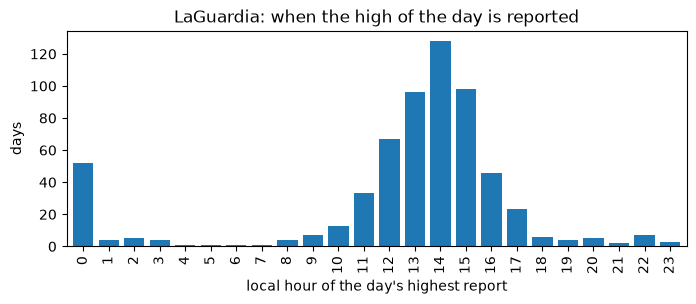

,city,n_events,share_before_06
0,Toronto,297,0.145
1,Wellington,251,0.143
2,Chongqing,194,0.129
3,NYC,611,0.110
4,Tokyo,204,0.108
5,Chicago,251,0.092


In [12]:
peak_hours = q("""
    SELECT hour(t_max_local) AS hour, count(*) AS days
    FROM truth
    WHERE station = 'KLGA' AND n_obs > 0
    GROUP BY 1
    ORDER BY 1
""").set_index("hour").days

fig, ax = plt.subplots(figsize=(8, 2.8))
peak_hours.plot.bar(ax=ax, width=0.8)
ax.set_xlabel("local hour of the day's highest report")
ax.set_ylabel("days")
ax.set_title("LaGuardia: when the high of the day is reported")
plt.show()

early = q("""
    SELECT city, count(*) AS n_events,
           round(avg((hour(t_max_local) < 6)::int), 3) AS share_before_06
    FROM truth
    WHERE n_obs > 0
    GROUP BY 1
    HAVING count(*) > 100
    ORDER BY 3 DESC
    LIMIT 6
""")
early

### One day in ten, the high is in before breakfast

At LaGuardia 11% of days peak before 06:00 local. Toronto and Wellington are at 14%. The bar at
midnight is the first report of a day that only gets colder. The same-day model in notebook 03
handles this by treating the running maximum as a floor rather than as an estimate.

## The label for every day, not just market days

**Markets exist for about 600 days per city. Station reports exist for every day.** The rebuild
runs over every station-day in the archive, so the model has a label to train on whether or not a
market existed. That is the `daily_truth` table.

In [13]:
labels = q("""
    SELECT d.station, count(*) AS station_days, min(d.day) AS first, max(d.day) AS last,
           round(avg(d.n_obs), 1) AS reports_per_day,
           count(t.event_id) AS with_a_market
    FROM daily_truth d
    LEFT JOIN truth t ON t.station = d.station AND t.date = d.day
    WHERE d.station IN ('EGLC', 'KLGA')
    GROUP BY 1
""")
labels

,station,station_days,first,last,reports_per_day,with_a_market
0,EGLC,639,2025-01-01,2026-09-30,47.9,613
1,KLGA,638,2025-01-01,2026-09-29,27.4,611


In [14]:
con.close()

## What this notebook establishes

**The target is the displayed value, and it can be rebuilt.** For a Fahrenheit market: the T-group
tenths of each report, converted to Fahrenheit, rounded half up, maximum over the local clock day.
For a Celsius market: the whole-degree METAR value. For Hong Kong: the Observatory's maximum with
the decimal cut off. The rebuild agrees with Polymarket's payout on 99.7% of Fahrenheit days and 96
to 99% of Celsius days, and SPECI reports count. Events with no station report at all are left out
of those rates.

**The rounding chain creates no mispriced buckets.** The whole-degree rule would make half the
Fahrenheit values impossible, and the market's own payouts show they are not.

**Everything downstream scores against this value.** The model in notebook 03 trains on the
continuous Celsius label from every station-day, converts to the market's unit at scoring time, and
integrates its distribution between half-integer edges, which is exactly where the rounding lives.